# Phase 6: Error Analysis

This phase evaluates the model performance by analyzing residual errors. Residual plots help determine whether the model predictions are unbiased and reliable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/Data-Driven-Energy-Project')

Mounted at /content/drive


In [3]:
df = pd.read_csv("data/energy_efficiency.csv", encoding='latin1')

df.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Distribution",
    "Heating_Load",
    "Cooling_Load"
]


In [4]:
df = df.dropna()

TRAIN BEST MODEL (Random Forest)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df.drop(["Heating_Load", "Cooling_Load"], axis=1)
y = df["Heating_Load"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

RESIDUAL ANALYSIS

In [6]:
residuals = y_test - pred

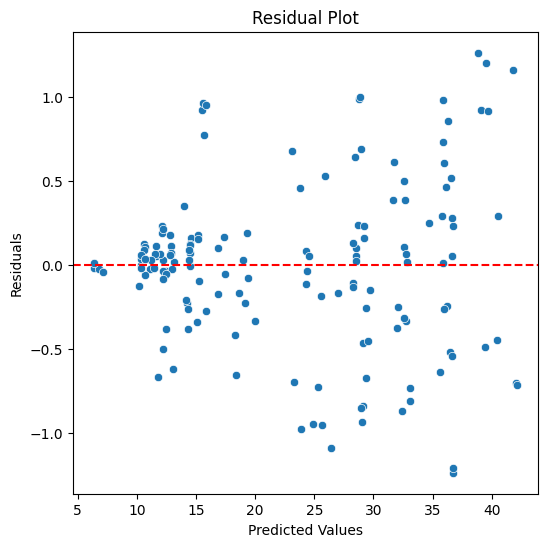

In [7]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=pred, y=residuals)

plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.savefig("outputs/graphs/12_residual_plot.png")

plt.show()

RESIDUAL DISTRIBUTION

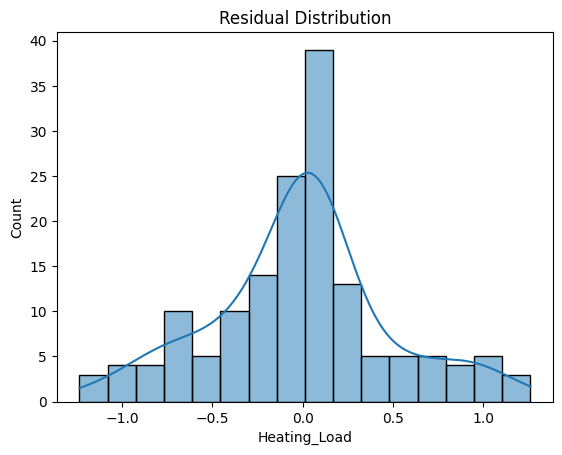

In [8]:
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.savefig("outputs/graphs/13_residual_distribution.png")

plt.show()

Residual analysis was performed to evaluate model performance. The residual plot shows that errors are randomly distributed around zero, indicating that the model does not exhibit systematic bias. The residual distribution is approximately normal, suggesting that the model predictions are reliable and well-generalized.